# **Model Deteksi Emosi Wajah**
## Warasin — AI Engineer
---

In [31]:
import google.colab as gc
gc.drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import os
os.chdir('/content/drive/MyDrive/capstone_AI/input/Facial Expression Dataset')

## Import Library
---

In [33]:
!pip install tensorflow # Ensure TensorFlow is installed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

In [34]:
from tensorflow.keras import mixed_precision

# Aktifkan mixed precision untuk performa yang lebih cepat di GPU modern
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision policy set to 'mixed_float16'.")


Mixed precision policy set to 'mixed_float16'.


## Load Dataset
---

### Data Loading and Preprocessing with `tf.data.Dataset`

In [35]:
import os
import tensorflow as tf
import numpy as np

# Get the original class names from the directory structure
# This assumes 'train' directory exists in the current working directory.
original_class_names_from_dir = sorted(os.listdir('train'))
print(f"Original class names from directory: {original_class_names_from_dir}")

# Identify the index of the 'disgust' class in the original sorted list
disgust_class_index = -1
if 'disgust' in original_class_names_from_dir:
    disgust_class_index = original_class_names_from_dir.index('disgust')
    print(f"Disgust class found at original index: {disgust_class_index}")
else:
    print("Disgust class not found in directory. No filtering needed.")

# Define the new list of class names after removing 'disgust'
target_class_names = [name for name in original_class_names_from_dir if name != 'disgust']
print(f"Target class names (without disgust): {target_class_names}")
num_target_classes = len(target_class_names)
print(f"Number of target classes: {num_target_classes}")

# Function to collect file paths and integer labels (from cell 27cf4d78)
def get_paths_and_labels(data_dir, class_names):
    paths = []
    labels = [] # Integer labels
    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.exists(class_path):
            print(f"Warning: Directory not found: {class_path}")
            continue
        for img_name in os.listdir(class_path):
            paths.append(os.path.join(class_path, img_name))
            labels.append(class_idx)
    return np.array(paths), np.array(labels)

print(f"Collecting file paths and labels...")
train_paths, train_int_labels = get_paths_and_labels('train', target_class_names)
val_paths, val_int_labels = get_paths_and_labels('test', target_class_names)
print(f"Finished collecting file paths and labels.")

# Update the global class_names and num_classes for subsequent cells
class_names = target_class_names
num_classes = num_target_classes


Original class names from directory: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Disgust class found at original index: 1
Target class names (without disgust): ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of target classes: 6
Finished collecting file paths and labels.


### Konversi Dataset ke TFRecord (Jalankan Sekali Saja)

Karena RAM tidak cukup untuk memuat semua data ke memori sekaligus, kita akan menggunakan TFRecord. TFRecord adalah format biner yang sangat efisien untuk menyimpan data pelatihan, memungkinkan TensorFlow membaca data lebih cepat dari disk. Ini akan meningkatkan kecepatan pipeline data secara signifikan.

**Penting:** Sel ini hanya perlu dijalankan **sekali** untuk membuat file `train.tfrecord` dan `val.tfrecord`. Setelah file-file ini dibuat, Anda dapat mengomentari atau menghapus sel ini.

In [36]:
import tensorflow as tf
import os
from tqdm.auto import tqdm # Import tqdm for progress bar

# Pastikan IMG_SIZE dan target_class_names konsisten
IMG_SIZE = 96
TRAIN_DIR = 'train'
VAL_DIR = 'test'
target_class_names = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Nama file TFRecord
TRAIN_TFRECORD_PATH = 'train.tfrecord'
VAL_TFRECORD_PATH = 'val.tfrecord'

import random

def create_tfrecord(
    directory,
    output_path,
    img_size=IMG_SIZE,
    class_names=target_class_names
):

    writer = tf.io.TFRecordWriter(output_path)

    all_samples = []

    # kumpulkan semua file
    for label_idx, class_name in enumerate(class_names):

        class_dir = os.path.join(
            directory,
            class_name
        )

        if not os.path.exists(class_dir):
            continue

        files = [
            f for f in os.listdir(class_dir)
            if f.lower().endswith(
                ('.jpg', '.jpeg', '.png')
            )
        ]

        print(
            f"Processing {class_name}: "
            f"{len(files)} gambar "
            f"(Label {label_idx})"
        )

        for fname in files:
            all_samples.append(
                (
                    os.path.join(
                        class_dir,
                        fname
                    ),
                    label_idx
                )
            )

    # SHUFFLE GLOBAL
    random.shuffle(all_samples)

    print(
        f"\nWriting "
        f"{len(all_samples)} samples..."
    )

    for fpath, label_idx in tqdm(all_samples):

        try:
            img = tf.io.read_file(fpath)

            img = tf.image.decode_jpeg(
                img,
                channels=3
            )

            img = tf.image.resize(
                img,
                [img_size, img_size]
            )

            img_bytes = tf.image.encode_jpeg(
                tf.cast(img, tf.uint8)
            ).numpy()

            feature = {
                'image': tf.train.Feature(
                    bytes_list=tf.train.BytesList(
                        value=[img_bytes]
                    )
                ),

                'label': tf.train.Feature(
                    int64_list=tf.train.Int64List(
                        value=[label_idx]
                    )
                )
            }

            example = tf.train.Example(
                features=tf.train.Features(
                    feature=feature
                )
            )

            writer.write(
                example.SerializeToString()
            )

        except Exception:
            continue

    writer.close()

    print(
        f"Saved → {output_path}"
    )

# Modifikasi: Cek keberadaan file sebelum membuat ulang
should_create_tfrecords = False # Set True untuk memaksa pembuatan ulang

if os.path.exists(TRAIN_TFRECORD_PATH) and os.path.exists(VAL_TFRECORD_PATH) and not should_create_tfrecords:
    print(f"TFRecord files '{TRAIN_TFRECORD_PATH}' dan '{VAL_TFRECORD_PATH}' sudah ada. Melewati pembuatan ulang.")
else:
    print("Membuat ulang TFRecords...")
    create_tfrecord(TRAIN_DIR, TRAIN_TFRECORD_PATH)
    create_tfrecord(VAL_DIR, VAL_TFRECORD_PATH)


Membuat ulang TFRecords...
Processing angry: 3995 gambar (Label 0)
Processing fear: 4097 gambar (Label 1)
Processing happy: 7215 gambar (Label 2)
Processing neutral: 4965 gambar (Label 3)
Processing sad: 4830 gambar (Label 4)
Processing surprise: 3171 gambar (Label 5)

Writing 28273 samples...


  0%|          | 0/28273 [00:00<?, ?it/s]

Saved → train.tfrecord
Processing angry: 958 gambar (Label 0)
Processing fear: 1024 gambar (Label 1)
Processing happy: 1774 gambar (Label 2)
Processing neutral: 1233 gambar (Label 3)
Processing sad: 1247 gambar (Label 4)
Processing surprise: 831 gambar (Label 5)

Writing 7067 samples...


  0%|          | 0/7067 [00:00<?, ?it/s]

Saved → val.tfrecord


In [56]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

def parse_tfrecord(example_proto):
    feature_desc = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64)
    }
    parsed = tf.io.parse_single_example(example_proto, feature_desc)

    # Decode image
    img = tf.image.decode_jpeg(parsed['image'], channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    # PENTING: Gunakan preprocess_input bawaan EfficientNet
    # Ini menangani normalisasi yang tepat sesuai pre-trained weights
    img = preprocess_input(img)

    label = tf.one_hot(tf.cast(parsed['label'], tf.int32), depth=6)
    return img, label

def load_tfrecord(tfrecord_path, batch_size=BATCH_SIZE, is_training=False):
    AUTOTUNE = tf.data.AUTOTUNE
    ds = tf.data.TFRecordDataset(tfrecord_path, num_parallel_reads=AUTOTUNE)
    ds = ds.map(parse_tfrecord, num_parallel_calls=AUTOTUNE)

    if is_training:
        ds = ds.shuffle(buffer_size=5000) # Buffer lebih besar untuk variasi
        ds = ds.repeat()

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = load_tfrecord(TRAIN_TFRECORD_PATH, is_training=True)
val_ds   = load_tfrecord(VAL_TFRECORD_PATH, is_training=False)
print("Dataset reloaded with EfficientNet preprocessing.")

Dataset reloaded with EfficientNet preprocessing.


### Exploring the New `tf.data.Dataset`

Found 28273 files belonging to 6 classes.


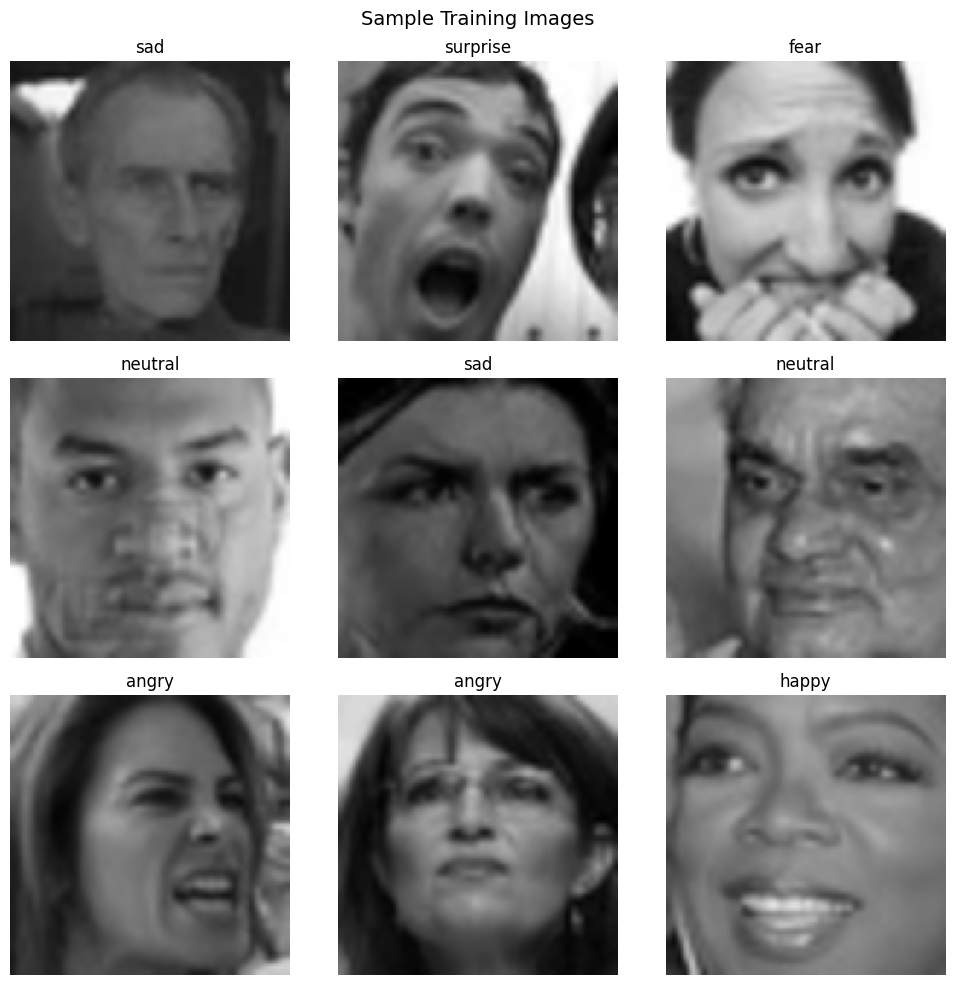

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os # For TRAIN_DIR if not global

# --- Dataset for visualization (User provided) ---
def get_dataset_viz(directory, img_size):
    """Dataset khusus visualisasi, TANPA normalisasi"""
    AUTOTUNE = tf.data.AUTOTUNE
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=(img_size, img_size),
        batch_size=9, # Take 9 images for visualization
        label_mode='categorical',
        class_names=target_class_names # Use target_class_names from cell 6623f083
    )
    return ds

# Create visualization dataset
viz_ds = get_dataset_viz(TRAIN_DIR, IMG_SIZE)

plt.figure(figsize=(10, 10))
for images, labels in viz_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Gambar masih 0-255, langsung cast uint8
        img = images[i].numpy().astype("uint8")
        plt.imshow(img)
        # class_names is from cell 6623f083
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


### Exploring the Loaded Dataset

Mari kita lihat beberapa informasi dasar tentang dataset yang baru saja kita muat.

Number of training batches: -1
Number of validation batches: -2
Class names: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


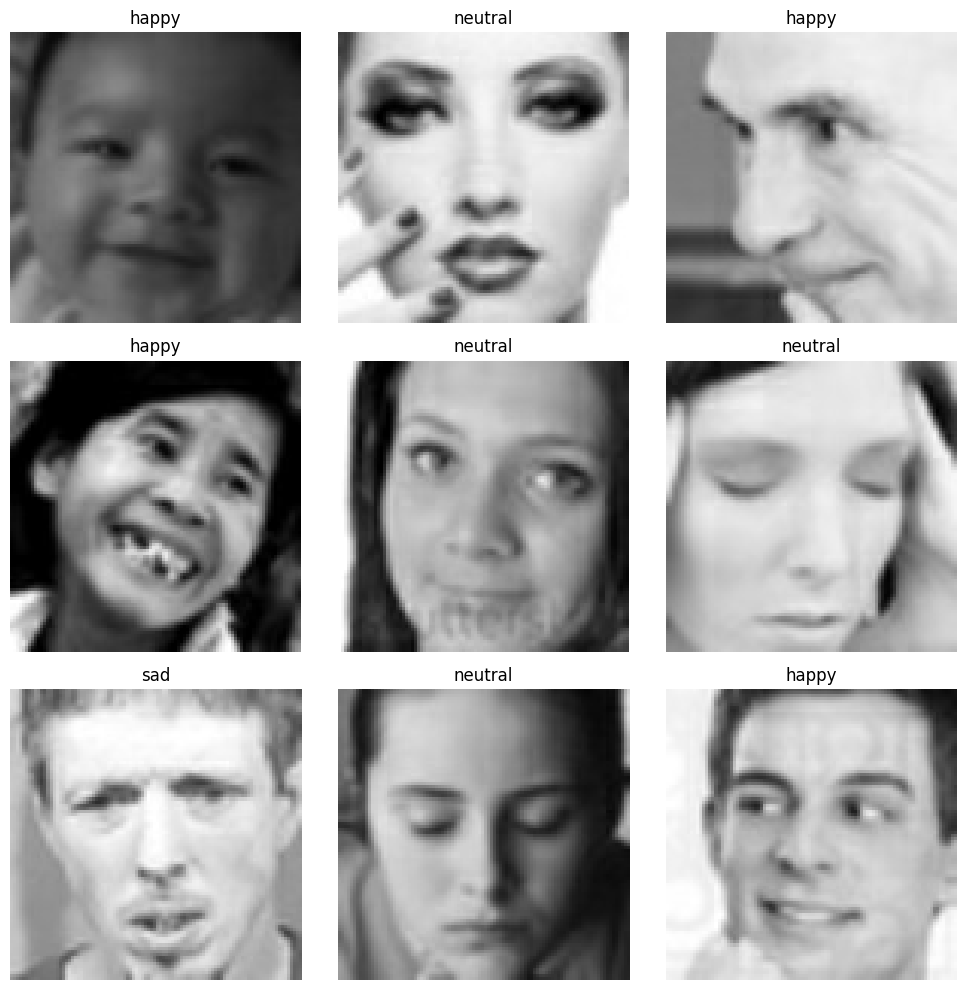

In [49]:
import os
import matplotlib.pyplot as plt
import numpy as np

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Class names: {class_names}")

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        img = images[i].numpy()          # nilai 0.0 - 1.0
        img = (img * 255).astype("uint8") # kembalikan ke 0-255

        plt.imshow(img, cmap='gray')
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [57]:
import numpy as np

print("Checking 5 batches distribution...\n")

for batch_idx, (_, lbs) in enumerate(train_ds.take(5)):

    labels = np.argmax(lbs.numpy(), axis=1)

    unique, counts = np.unique(labels, return_counts=True)

    print(f"Batch {batch_idx+1}")
    print(dict(zip(unique, counts)))
    print("-"*40)

Checking 5 batches distribution...

Batch 1
{np.int64(0): np.int64(15), np.int64(1): np.int64(7), np.int64(2): np.int64(16), np.int64(3): np.int64(11), np.int64(4): np.int64(9), np.int64(5): np.int64(6)}
----------------------------------------
Batch 2
{np.int64(0): np.int64(8), np.int64(1): np.int64(10), np.int64(2): np.int64(16), np.int64(3): np.int64(13), np.int64(4): np.int64(7), np.int64(5): np.int64(10)}
----------------------------------------
Batch 3
{np.int64(0): np.int64(7), np.int64(1): np.int64(7), np.int64(2): np.int64(17), np.int64(3): np.int64(9), np.int64(4): np.int64(14), np.int64(5): np.int64(10)}
----------------------------------------
Batch 4
{np.int64(0): np.int64(8), np.int64(1): np.int64(9), np.int64(2): np.int64(18), np.int64(3): np.int64(12), np.int64(4): np.int64(11), np.int64(5): np.int64(6)}
----------------------------------------
Batch 5
{np.int64(0): np.int64(8), np.int64(1): np.int64(8), np.int64(2): np.int64(20), np.int64(3): np.int64(12), np.int64(4):

### Data Preprocessing and Augmentation with `ImageDataGenerator`

In [41]:
# ImageDataGenerator is deprecated and replaced by tf.data.Dataset pipeline for faster data loading and preprocessing.
# See cells above for the new tf.data pipeline setup (bfb6db36 and 27cf4d78).

### Contoh Augmentasi Data (Before vs After)

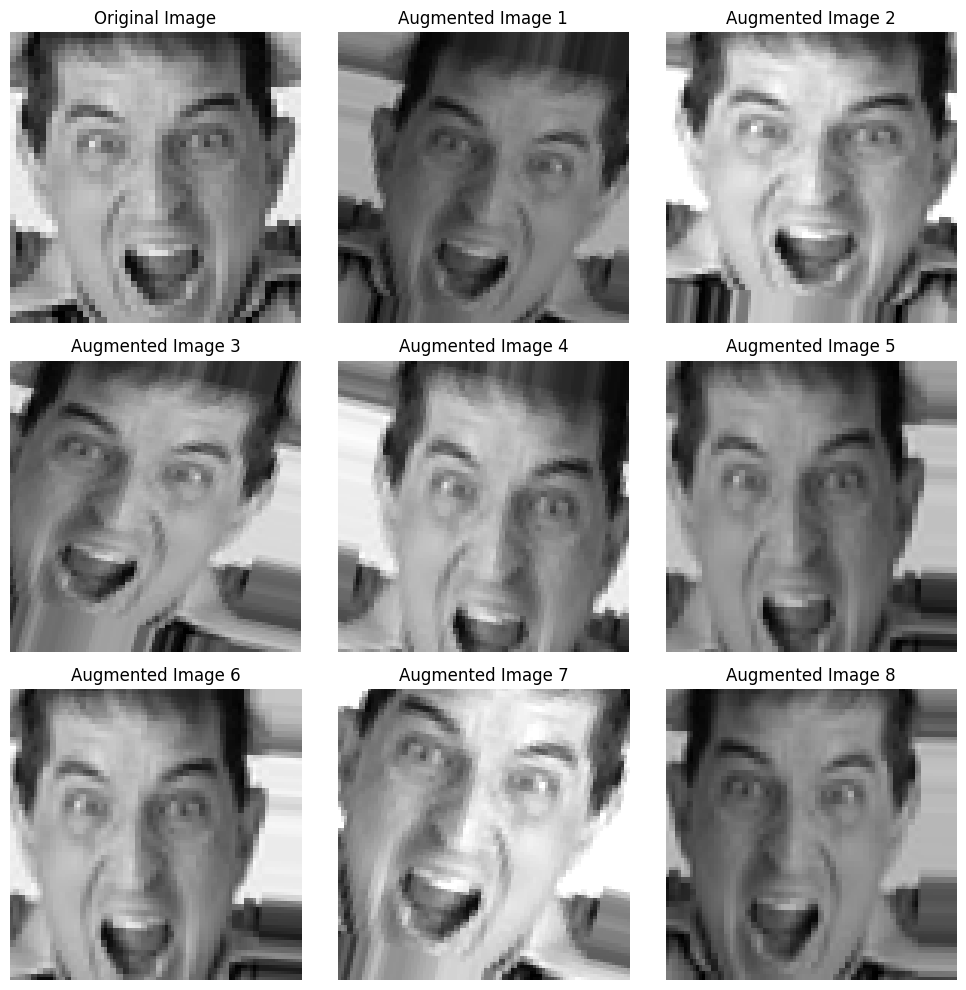

In [51]:
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array # Added these imports

# Datagen khusus visualisasi - TANPA rescale!
viz_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.7, 1.3], # Using same brightness range as train_datagen
    shear_range=0.1,
    fill_mode='nearest'
    # TIDAK ADA rescale=1./255 di sini
)

# Find a sample image path
sample_image_path = os.path.join('train', 'angry', os.listdir(os.path.join('train', 'angry'))[0])

# Load gambar tanpa normalisasi
img = load_img(sample_image_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = img_to_array(img)  # nilai 0-255
img_array = np.expand_dims(img_array, axis=0) # Reshape to (1, IMG_SIZE, IMG_SIZE, 3)

# Generate dan tampilkan
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes[0, 0].imshow(img_array[0].astype('uint8'), cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

aug_iter = viz_datagen.flow(img_array, batch_size=1)
for i, ax in enumerate(axes.flatten()[1:]):
    if i >= 8: # Limit to 8 augmented images for a 3x3 grid (1 original + 8 augmented)
        break
    aug_img = next(aug_iter)[0].astype('uint8')
    ax.imshow(aug_img, cmap='gray')
    ax.set_title(f'Augmented Image {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Menghitung Class Weights

In [52]:
from sklearn.utils.class_weight import compute_class_weight

# Get the integer labels from the training dataset (from tf.data setup)
# Using train_int_labels which was collected during the tf.data pipeline setup.
y_train_labels = train_int_labels

# Get the unique class labels (0 to num_target_classes - 1)
classes = np.arange(num_target_classes)

# Compute class weights using 'balanced' method
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_labels
)

# Convert the array to a dictionary for easier lookup with class names
class_weights_dict = dict(zip(classes, class_weights_array))

print("Class Weights (balanced):")
for class_idx, class_name in enumerate(target_class_names):
    print(f"  {class_name}: {class_weights_dict[class_idx]:.4f}")

# Convert to a dictionary where keys are class indices (as integers) for use in model.fit
model_class_weights = {class_idx: weight for class_idx, weight in enumerate(class_weights_array)}
print("\nClass weights in dictionary format for model training:")
print(model_class_weights)


Class Weights (balanced):
  angry: 1.1795
  fear: 1.1502
  happy: 0.6531
  neutral: 0.9491
  sad: 0.9756
  surprise: 1.4860

Class weights in dictionary format for model training:
{0: np.float64(1.1795160617438465), 1: np.float64(1.1501505166381905), 2: np.float64(0.6531069531069531), 3: np.float64(0.9490768714333669), 4: np.float64(0.9756038647342995), 5: np.float64(1.486019131714496)}


### Building the Model with EfficientNetB2 Backbone

In [58]:
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras import layers, models, regularizers

# Augmentasi yang lebih ringan untuk Phase 1 agar model stabil
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1), # Diperkecil dari 0.25
    layers.RandomZoom(0.1),
])

base_model = EfficientNetB2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                              include_top=False,
                              weights='imagenet')

base_model.trainable = False # Tetap freeze di Phase 1

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x) # Hapus L2 sementara untuk mempermudah konvergensi
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(6, activation='softmax', dtype='float32')(x) # Pastikan float32 untuk output

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model rebuilt with simplified augmentation and standard head.")
model.summary()

Model rebuilt with simplified augmentation and standard head.


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 3, 3, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       360,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,136,447 (31.04 MB)

 Trainable params: 365,062 (1.39 MB)

 Non-trainable params: 7,771,385 (29.65 MB)

In [59]:
import tensorflow as tf

# Verifikasi Final Layer sebelum compile
print(f"Output shape: {model.output_shape}")
print(f"Final Activation: {model.layers[-1].activation.__name__}")

# Re-compile with explicit config
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("Model re-compiled with CategoricalCrossentropy (Multiclass).")

Output shape: (None, 6)
Final Activation: softmax
Model re-compiled with CategoricalCrossentropy (Multiclass).


### Training Awal

In [60]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard

EPOCHS_PHASE1 = 10

# Calculate steps per epoch for tf.data.Dataset
# Use len(train_paths) and len(val_paths) as the dataset length for steps_per_epoch
steps_per_epoch_train = int(tf.math.ceil(len(train_paths) / BATCH_SIZE).numpy())
validation_steps_val = int(tf.math.ceil(len(val_paths) / BATCH_SIZE).numpy())

# Define callbacks for Phase 1
checkpoint_filepath_phase1 = 'best_model_phase1.keras'

callbacks_phase1 = [
    ModelCheckpoint(
        filepath=checkpoint_filepath_phase1,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        mode='max',
        verbose=1
    ),
    TensorBoard(log_dir='logs/fit/phase1')
]

print(f"Starting Phase 1 training for {EPOCHS_PHASE1} epochs...")
print(f"Steps per epoch (train): {steps_per_epoch_train}")
print(f"Steps per epoch (val): {validation_steps_val}")

history_phase1 = model.fit(
    train_ds, # Use tf.data.Dataset for training
    steps_per_epoch=steps_per_epoch_train,
    epochs=EPOCHS_PHASE1,
    validation_data=val_ds, # Use tf.data.Dataset for validation
    validation_steps=validation_steps_val,
    class_weight=model_class_weights, # Apply class weights
    callbacks=callbacks_phase1,
    verbose=1
)

print("Phase 1 training completed.")

# Display final validation accuracy
final_val_accuracy_phase1 = max(history_phase1.history['val_accuracy'])
print(f"\nFinal Validation Accuracy (Phase 1): {final_val_accuracy_phase1:.4f}")

Starting Phase 1 training for 10 epochs...
Steps per epoch (train): 442
Steps per epoch (val): 111
Epoch 1/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3161 - loss: 1.9968
Epoch 1: val_accuracy improved from None to 0.45054, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 53s 81ms/step - accuracy: 0.3504 - loss: 1.7986 - val_accuracy: 0.4505 - val_loss: 1.4851 - learning_rate: 0.0010
Epoch 2/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4149 - loss: 1.5556
Epoch 2: val_accuracy improved from 0.45054 to 0.47984, saving model to best_model_phase1.keras

Epoch 2: finished saving model to best_model_phase1.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.4146 - loss: 1.5535 - val_accuracy: 0.4798 - val_loss: 1.4393 - learning_rate: 0.0010
Epoch 3/10
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4355 - loss: 1.5168
Epoch 3: val_accuracy did not improve from 0.47

### Phase 2: Fine-tuning (Unfreeze 40% of Backbone Layers)

In [61]:
# 1. Unfreeze the base_model (EfficientNetB2)
base_model.trainable = True

# 2. Freeze the first 60% layers, unfreeze the last 40%
# Calculate the index to split the layers
num_layers_backbone = len(base_model.layers)
freeze_until_index = int(num_layers_backbone * 0.6)

print(f"Total layers in EfficientNetB2 backbone: {num_layers_backbone}")
print(f"Freezing layers up to index: {freeze_until_index} (first 60%)")

for layer in base_model.layers[:freeze_until_index]:
    layer.trainable = False

for layer in base_model.layers[freeze_until_index:]:
    layer.trainable = True

# Display the number of trainable layers before recompiling and training
print("\nNumber of trainable layers in the model (before Phase 2 training):")
for layer in model.layers:
    if layer.trainable:
        print(f"  - {layer.name}")

trainable_params_phase2 = 0
for layer in model.layers:
    trainable_params_phase2 += sum([np.prod(p.shape) for p in layer.trainable_weights])
print(f"Total trainable parameters for Phase 2: {trainable_params_phase2}")


Total layers in EfficientNetB2 backbone: 340
Freezing layers up to index: 204 (first 60%)

Number of trainable layers in the model (before Phase 2 training):
  - input_layer_10
  - sequential_3
  - efficientnetb2
  - global_average_pooling2d_3
  - batch_normalization_3
  - dense_6
  - dropout_6
  - dense_7
Total trainable parameters for Phase 2: 7123932


In [62]:
# 3. Recompile with a smaller learning rate (Adam lr=1e-4)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
print("Model recompiled successfully for Phase 2 fine-tuning.")

# Update callbacks for Phase 2
checkpoint_filepath_phase2 = 'best_model_phase2.keras'

callbacks_phase2 = [
    ModelCheckpoint(
        filepath=checkpoint_filepath_phase2,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-7, # Even smaller min_lr for fine-tuning
        mode='max',
        verbose=1
    ),
    TensorBoard(log_dir='logs/fit/phase2')
]


Model recompiled successfully for Phase 2 fine-tuning.


In [63]:
EPOCHS_PHASE2 = 30

print(f"Starting Phase 2 fine-tuning for {EPOCHS_PHASE2} epochs...")

history_phase2 = model.fit(
    train_ds, # Use tf.data.Dataset for training
    steps_per_epoch=steps_per_epoch_train,
    epochs=EPOCHS_PHASE2,
    validation_data=val_ds, # Use tf.data.Dataset for validation
    validation_steps=validation_steps_val,
    class_weight=model_class_weights,
    callbacks=callbacks_phase2,
    verbose=1
)

print("Phase 2 fine-tuning completed.")

# Display final validation accuracy for Phase 2
final_val_accuracy_phase2 = max(history_phase2.history['val_accuracy'])
print(f"\nFinal Validation Accuracy (Phase 2): {final_val_accuracy_phase2:.4f}")


Starting Phase 2 fine-tuning for 30 epochs...
Epoch 1/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3659 - loss: 1.6117
Epoch 1: val_accuracy improved from None to 0.50601, saving model to best_model_phase2.keras

Epoch 1: finished saving model to best_model_phase2.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 94s 128ms/step - accuracy: 0.4106 - loss: 1.5560 - val_accuracy: 0.5060 - val_loss: 1.4068 - learning_rate: 1.0000e-04
Epoch 2/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4856 - loss: 1.4336
Epoch 2: val_accuracy improved from 0.50601 to 0.54889, saving model to best_model_phase2.keras

Epoch 2: finished saving model to best_model_phase2.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 56s 127ms/step - accuracy: 0.4960 - loss: 1.4218 - val_accuracy: 0.5489 - val_loss: 1.3230 - learning_rate: 1.0000e-04
Epoch 3/30
442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5333 - loss: 1.3555
Epoch 3: val_accuracy improved from 0.54889 to 0.57436, saving model to best_model_phas

### Visualisasi Riwayat Pelatihan (Phase 1 & Phase 2)

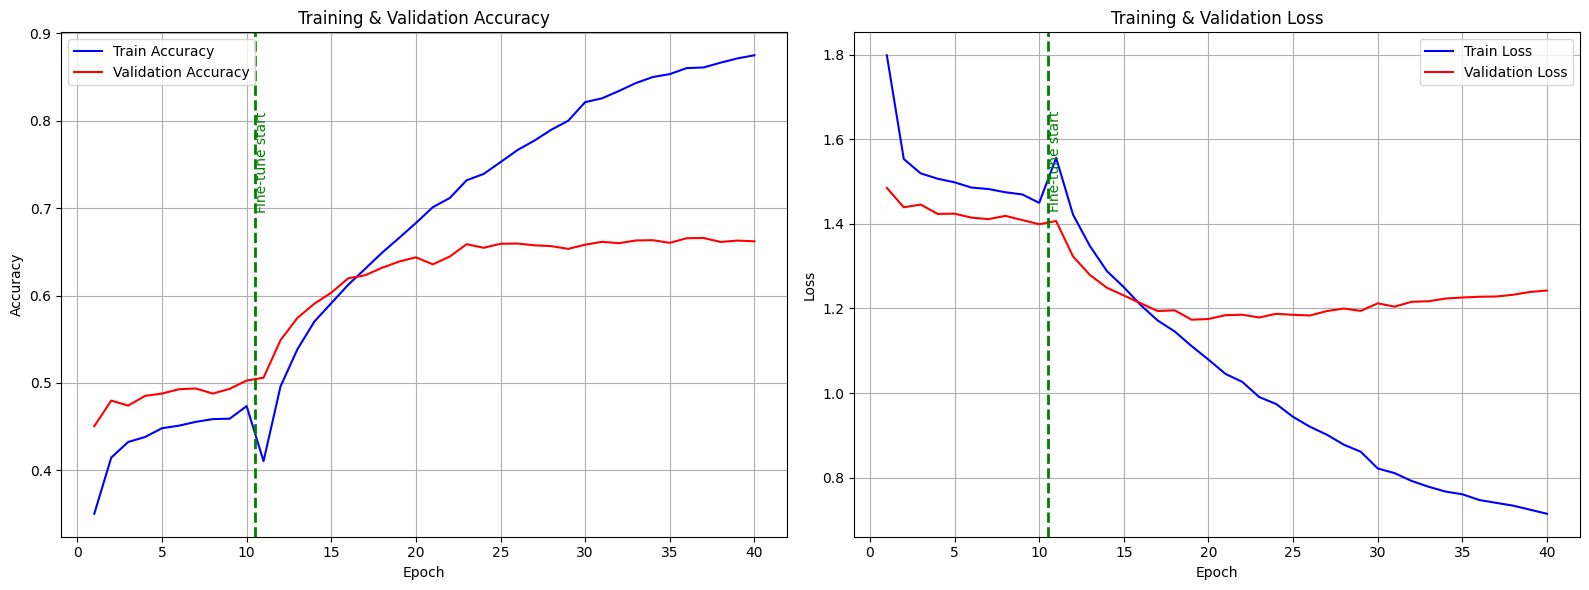

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Gabungkan history_phase1 dan history_phase2
# Pastikan Anda menggunakan atribut .history dari objek History
combined_history = {}
for key in history_phase1.history.keys():
    combined_history[key] = history_phase1.history[key] + history_phase2.history[key]

# Hitung jumlah epoch total
total_epochs = len(combined_history['accuracy'])

# Posisi garis vertikal untuk memisahkan Phase 1 dan Phase 2
# Ini adalah epoch terakhir dari Phase 1, sebelum Phase 2 dimulai.
fine_tune_start_epoch = len(history_phase1.history['accuracy']) # Index is 0-based, so this is the count of epochs in phase 1

# 2. Plot 2 grafik berdampingan: Akurasi dan Loss
plt.figure(figsize=(16, 6))

# Grafik Kiri: Train Accuracy vs Val Accuracy
plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
plt.plot(range(1, total_epochs + 1), combined_history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(range(1, total_epochs + 1), combined_history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Tambahkan garis vertikal
plt.axvline(x=fine_tune_start_epoch + 0.5, color='green', linestyle='--', linewidth=2, label='Fine-tune Start')
# Mengatur label garis vertikal agar tidak tumpang tindih dengan data
# Anda bisa menyesuaikan posisi y dan x teks jika perlu
plt.text(fine_tune_start_epoch + 0.5, plt.ylim()[1] * 0.9, 'Fine-tune start', color='green', ha='left', va='top', rotation=90)


# Grafik Kanan: Train Loss vs Val Loss
plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
plt.plot(range(1, total_epochs + 1), combined_history['loss'], label='Train Loss', color='blue')
plt.plot(range(1, total_epochs + 1), combined_history['val_loss'], label='Validation Loss', color='red')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Tambahkan garis vertikal
plt.axvline(x=fine_tune_start_epoch + 0.5, color='green', linestyle='--', linewidth=2)
plt.text(fine_tune_start_epoch + 0.5, plt.ylim()[1] * 0.9, 'Fine-tune start', color='green', ha='left', va='top', rotation=90)

plt.tight_layout()

# 4. Simpan grafik sebagai training_history.png
plt.savefig('training_history.png')
plt.show()

### 1. Evaluasi pada `val_ds`

In [65]:
print("\n--- Final Evaluation on Validation Dataset ---")
val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_accuracy:.4f}")


--- Final Evaluation on Validation Dataset ---
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.6658 - loss: 1.2284
Final Validation Loss: 1.2284
Final Validation Accuracy: 0.6658


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


### 2. Confusion Matrix & 3. Classification Report

Untuk membuat *confusion matrix* dan *classification report*, kita perlu mendapatkan semua label sebenarnya dan prediksi dari *validation dataset*.

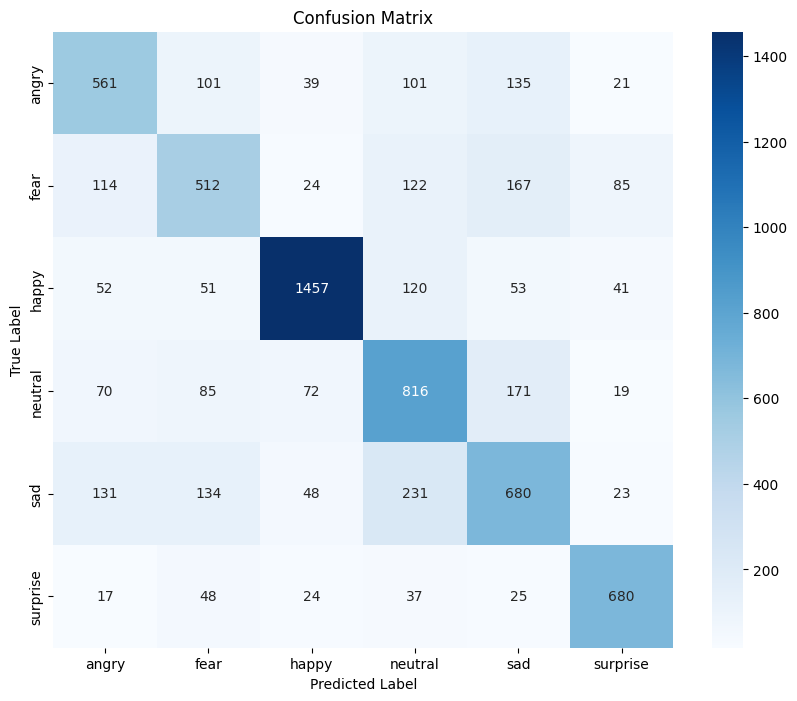


--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.59      0.59      0.59       958
        fear       0.55      0.50      0.52      1024
       happy       0.88      0.82      0.85      1774
     neutral       0.57      0.66      0.61      1233
         sad       0.55      0.55      0.55      1247
    surprise       0.78      0.82      0.80       831

    accuracy                           0.67      7067
   macro avg       0.65      0.66      0.65      7067
weighted avg       0.67      0.67      0.67      7067



In [66]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Collect true labels and predictions
all_true_labels = []
all_predictions = []

print("Collecting predictions for validation dataset...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0) # Predict probabilities
    all_predictions.extend(np.argmax(preds, axis=1)) # Get predicted class index
    all_true_labels.extend(np.argmax(labels.numpy(), axis=1)) # Get true class index

all_true_labels = np.array(all_true_labels)
all_predictions = np.array(all_predictions)

# Generate Confusion Matrix
cm = confusion_matrix(all_true_labels, all_predictions)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_class_names, yticklabels=target_class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

print("\n--- Classification Report ---")
print(classification_report(all_true_labels, all_predictions, target_names=target_class_names))

### 4. Plot Top 9 Gambar yang Salah Diprediksi

Kita akan mencari gambar-gambar di mana model membuat prediksi yang salah dan menampilkannya.

Identifying misclassified images...


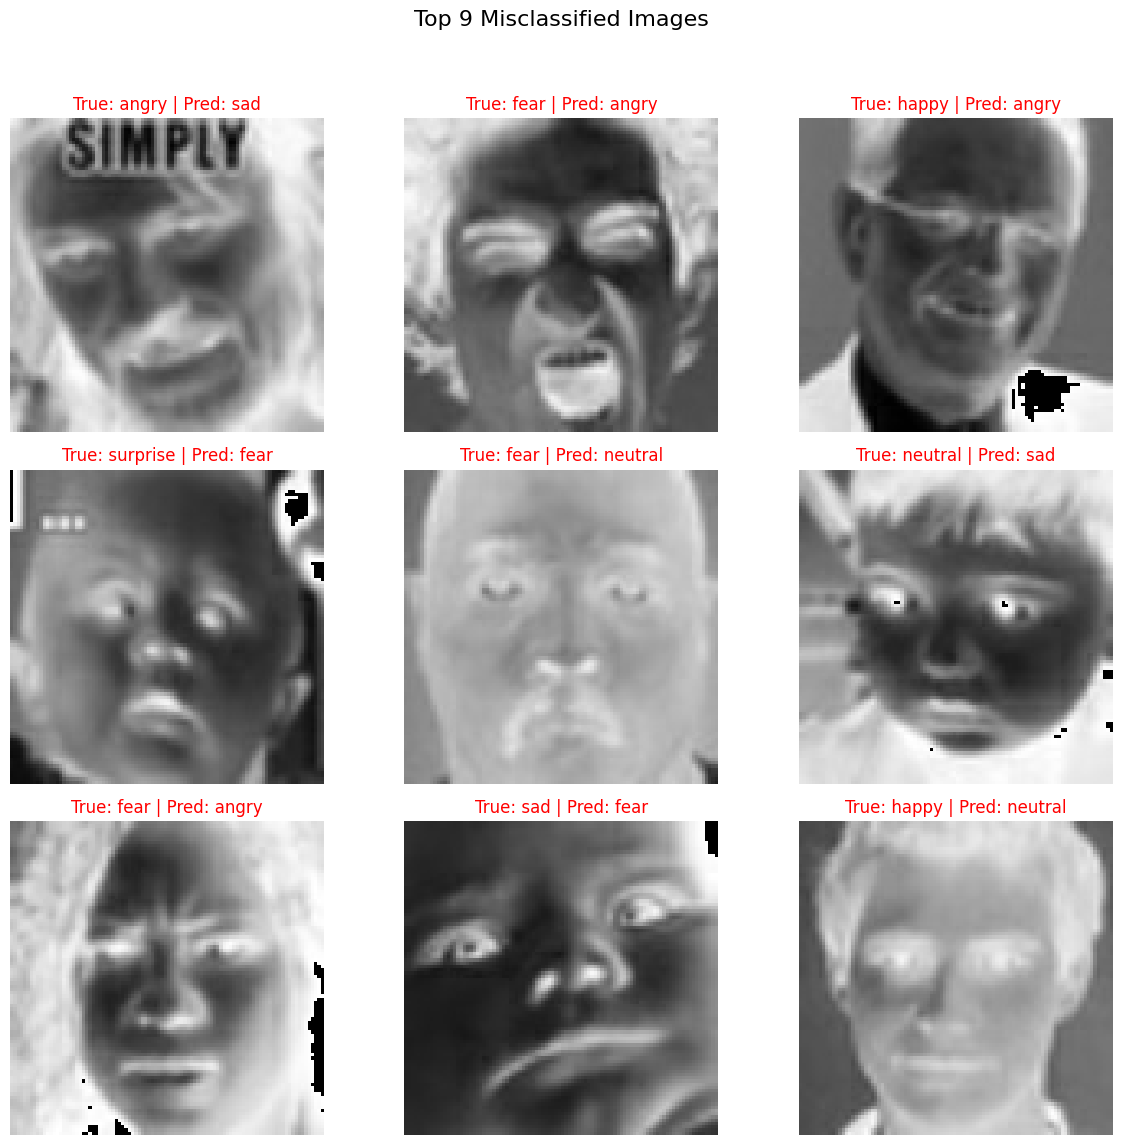

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Re-iterate through val_ds to get images, true labels, and predictions together
# This time, we'll store misclassified examples.

misclassified_images = []
misclassified_true_labels = []
misclassified_pred_labels = []

# Limit the number of images to check to avoid excessive processing for very large datasets
# For this example, we'll iterate through the whole validation set.

print("Identifying misclassified images...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    predicted_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    # Find indices where prediction is incorrect
    incorrect_indices = np.where(predicted_classes != true_classes)[0]

    for idx in incorrect_indices:
        misclassified_images.append(images[idx].numpy())
        misclassified_true_labels.append(true_classes[idx])
        misclassified_pred_labels.append(predicted_classes[idx])

# Plot up to 9 misclassified images
num_to_plot = min(9, len(misclassified_images))

if num_to_plot > 0:
    plt.figure(figsize=(12, 12))
    for i in range(num_to_plot):
        plt.subplot(3, 3, i + 1)
        img = misclassified_images[i]
        # Assuming images are normalized [0,1], convert back to [0,255] for display
        plt.imshow((img * 255).astype('uint8'))

        true_label_name = target_class_names[misclassified_true_labels[i]]
        pred_label_name = target_class_names[misclassified_pred_labels[i]]

        plt.title(f"True: {true_label_name} | Pred: {pred_label_name}", color='red')
        plt.axis('off')
    plt.suptitle('Top 9 Misclassified Images', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('wrong_predictions.png')
    plt.show()
else:
    print("No misclassified images found (or model is perfect)!.")

## Menyimpan Model untuk Deployment

Kita akan menyimpan model dalam tiga format berbeda untuk mendukung berbagai skenario deployment web:

1.  **Format Keras Native** (`.keras`): Untuk tujuan *backup* dan *re-loading* di lingkungan Python/Keras.
2.  **Format SavedModel**: Digunakan oleh TensorFlow Serving untuk *deployment* model yang skalabel dan berkinerja tinggi.
3.  **Format TensorFlow.js**: Untuk menjalankan model langsung di *browser web* atau lingkungan Node.js.

In [68]:
# Format 1: Keras native (untuk backup)
model.save('emotion_model.keras')
print("Model disimpan dalam format Keras native: emotion_model.keras")

Model disimpan dalam format Keras native: emotion_model.keras


In [69]:
# Format 2: SavedModel (untuk TensorFlow Serving)
model.export('emotion_savedmodel')
print("Model disimpan dalam format SavedModel: emotion_savedmodel/")

Saved artifact at 'emotion_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_1409')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137298900164560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137298900164176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137298900165520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137293536165520: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  137293536165712: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  137298900164368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137298900166288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137298900165136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137298900167824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137298900168400: TensorSpec(shape=(), dtype=tf.resource, name

### Konversi ke TensorFlow.js

Untuk mengonversi model ke format TensorFlow.js, kita perlu menginstal `tensorflowjs` dan kemudian menggunakan `tensorflowjs_converter`.

In [70]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting un

In [ ]:
import subprocess
import os

# Format 3: TensorFlow.js (untuk web browser langsung)
# Menggunakan subprocess untuk menjalankan perintah command-line
try:
    subprocess.run([
        'tensorflowjs_converter',
        '--input_format=keras',
        'emotion_model.keras', # Model input
        'emotion_tfjs_model' # Output directory
    ], check=True, capture_output=True, text=True)
    print("Model berhasil dikonversi ke TensorFlow.js: emotion_tfjs_model/")
except subprocess.CalledProcessError as e:
    print(f"Error saat mengonversi ke TF.js: {e.stderr}")
except FileNotFoundError:
    print("Error: Perintah 'tensorflowjs_converter' tidak ditemukan. Pastikan 'tensorflowjs' sudah terinstal.")

### Verifikasi dan Ukuran File Model

In [ ]:
import os
import shutil

print("=== Verifikasi File Model ===")

print("\n--- Keras Model (.keras) ---")
keras_path = 'emotion_model.keras'
if os.path.exists(keras_path):
    keras_size = os.path.getsize(keras_path) / (1024 * 1024) # MB
    print(f"'emotion_model.keras' ditemukan. Ukuran: {keras_size:.2f} MB")
else:
    print("'emotion_model.keras' TIDAK ditemukan.")

print("\n--- SavedModel (emotion_savedmodel/) ---")
savedmodel_path = 'emotion_savedmodel'
if os.path.exists(savedmodel_path) and os.path.isdir(savedmodel_path):
    print("'emotion_savedmodel/' direktori ditemukan. Isinya:")
    for root, dirs, files in os.walk(savedmodel_path):
        for f in files:
            print(os.path.join(root, f))
    savedmodel_total_size = sum(os.path.getsize(os.path.join(root, file)) for root, dirs, files in os.walk(savedmodel_path) for file in files) / (1024 * 1024)
    print(f"Total ukuran SavedModel: {savedmodel_total_size:.2f} MB")
else:
    print("'emotion_savedmodel/' direktori TIDAK ditemukan.")

print("\n--- TensorFlow.js Model (emotion_tfjs_model/) ---")
tfjs_path = 'emotion_tfjs_model'
if os.path.exists(tfjs_path) and os.path.isdir(tfjs_path):
    print("'emotion_tfjs_model/' direktori ditemukan. Isinya:")
    for root, dirs, files in os.walk(tfjs_path):
        for f in files:
            print(os.path.join(root, f))
    tfjs_total_size = sum(os.path.getsize(os.path.join(root, file)) for root, dirs, files in os.walk(tfjs_path) for file in files) / (1024 * 1024)
    print(f"Total ukuran TF.js Model: {tfjs_total_size:.2f} MB")
else:
    print("'emotion_tfjs_model/' direktori TIDAK ditemukan atau konversi gagal.")

## Membuat Flask API untuk Deployment Model

Sekarang kita akan membuat *file* `app.py` yang berisi kode Flask API sederhana untuk meng-*-deploy* model deteksi emosi. API ini akan dapat menerima gambar (baik melalui *upload file* atau *base64* dari *webcam*) dan mengembalikan prediksi emosi.

Sebelum menjalankan API, kita perlu menginstal beberapa *library*.

In [ ]:
print("Menginstal dependencies untuk Flask API...")
!pip install flask flask-cors pillow tensorflow
print("Dependencies terinstal.")

In [ ]:
import os

flask_api_code = '''
from flask import Flask, request, jsonify
from flask_cors import CORS
import tensorflow as tf
import numpy as np
from PIL import Image
import io, base64, os

app = Flask(__name__)
CORS(app)

# Load model
MODEL_PATH  = 'emotion_model.keras'
CLASS_NAMES = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
IMG_SIZE    = 96
model       = tf.keras.models.load_model(MODEL_PATH)
print(f"Model loaded dari {MODEL_PATH}")

def preprocess_image(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img, dtype=np.float32) / 255.0
    return np.expand_dims(arr, axis=0)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Terima file upload
        if 'file' in request.files:
            image_bytes = request.files['file'].read()

        # Terima base64 dari webcam/canvas
        elif request.json and 'image' in request.json:
            base64_str  = request.json['image'].split(',')[-1]
            image_bytes = base64.b64decode(base64_str)
        else:
            return jsonify({'error': 'No image provided'}), 400

        img_array   = preprocess_image(image_bytes)
        predictions = model.predict(img_array, verbose=0)[0]
        pred_idx    = int(np.argmax(predictions))

        return jsonify({
            'emotion'    : CLASS_NAMES[pred_idx],
            'confidence' : float(predictions[pred_idx] * 100),
            'all_probs'  : {name: float(prob * 100)
                           for name, prob in zip(CLASS_NAMES, predictions)}
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'model': MODEL_PATH})

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)
'''

with open('app.py', 'w') as f:
    f.write(flask_api_code)

print("File 'app.py' berhasil dibuat.")
print("Untuk menjalankan API ini di Colab, Anda mungkin perlu menggunakan ngrok atau tool serupa untuk membuat tunnel ke localhost.")
print("Contoh:")
print("  !pip install pyngrok")
print("  from pyngrok import ngrok")
print("  ngrok_tunnel = ngrok.connect(5000)")
print("  print('Public URL:', ngrok_tunnel.public_url)")
print("  # Kemudian, jalankan 'python app.py' di terminal terpisah (atau sebagai proses latar belakang)")

In [ ]:
import os

train_classes = sorted(os.listdir(TRAIN_DIR))
val_classes = sorted(os.listdir(VAL_DIR))

print("TRAIN:", train_classes)
print("VAL:", val_classes)
print("MATCH:", train_classes == val_classes)

In [ ]:
for imgs, lbs in train_ds.take(1):
    unique_lbs = np.unique(
        np.argmax(lbs.numpy(), axis=1),
        return_counts=True
    )

    print(unique_lbs)